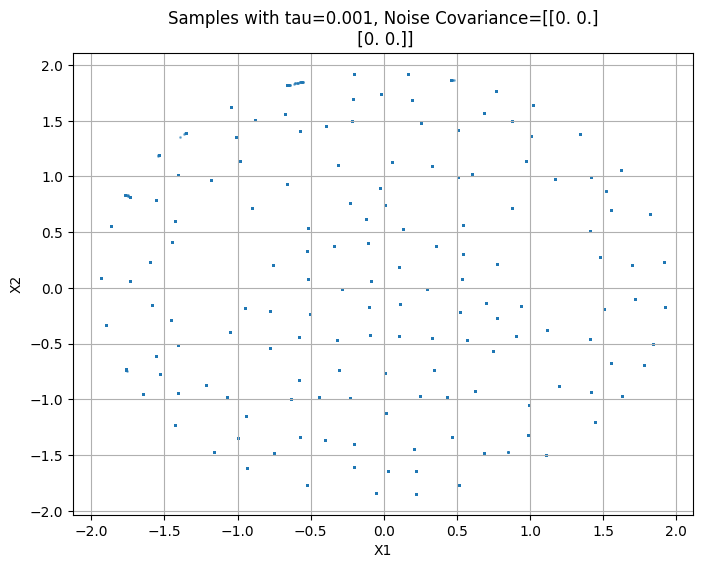

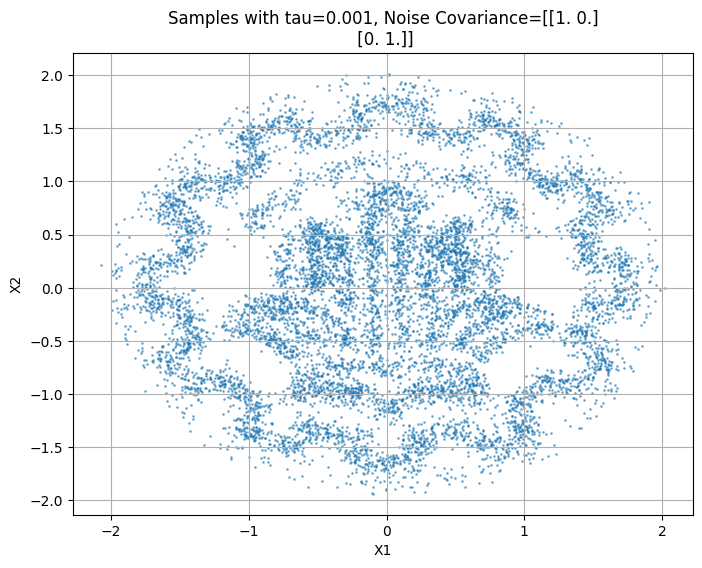

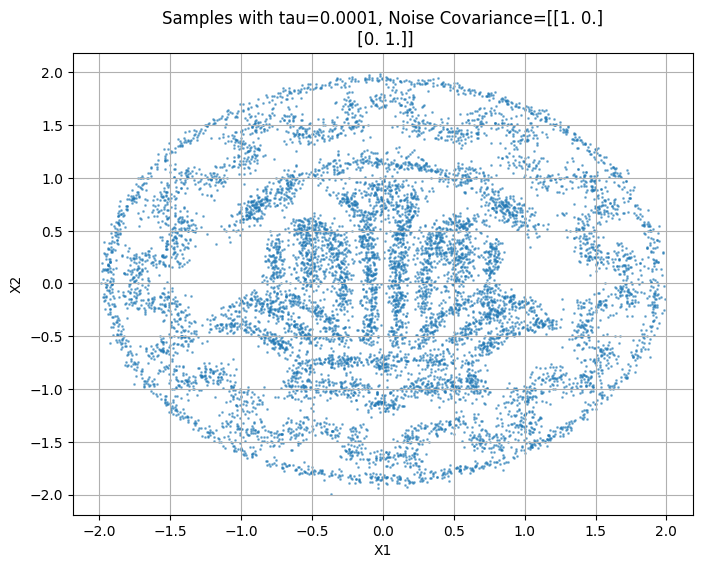

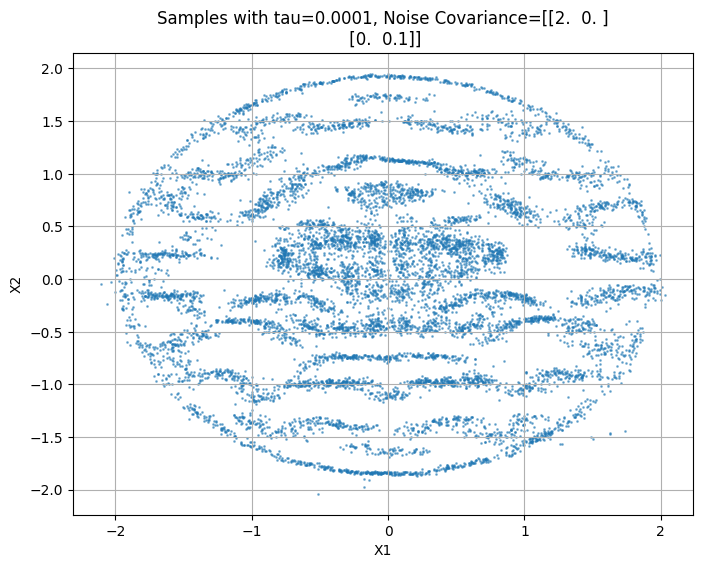

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load parameters from pickle file
parameters_file_path = 'DGM_SUT_H5_density.pkl'
with open(parameters_file_path, 'rb') as file:
    parameters = pickle.load(file)

# Simulation parameters
num_samples = 10 ** 4  # Number of initial samples
num_steps = 500  # Number of simulation steps
tau_values = [1e-3, 1e-3, 1e-4, 1e-4]  # Different step sizes
batch_size = 500  # Batch size for processing samples
noise_covariances = [np.zeros((2, 2)), np.eye(2), np.eye(2),
                     np.array([[2.0, 0.0], [0.0, 0.1]])]  # Noise covariance options

# Extract GMM parameters
weights, means, covariances = parameters['weights'], parameters['means'], parameters['covariances']
precomputed_inv_cov = [np.linalg.inv(cov) for cov in covariances]
precomputed_det_cov = [np.linalg.det(cov) for cov in covariances]


def log_pi_batched(x_batch):
    """Log of the target GMM distribution (batched)."""
    gmm_log_pdf = np.zeros(len(x_batch))
    for w, mu, inv_cov, det_cov in zip(weights, means, precomputed_inv_cov, precomputed_det_cov):
        diff = x_batch - mu
        exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
        gmm_log_pdf += w * np.exp(exponent) / np.sqrt((2 * np.pi) ** len(mu) * det_cov)
    return np.log(gmm_log_pdf)


def gradient_log_pi_batched(x_batch):
    """Gradient of the log of the target GMM distribution (batched)."""
    grad = np.zeros_like(x_batch)
    for w, mu, inv_cov, det_cov in zip(weights, means, precomputed_inv_cov, precomputed_det_cov):
        diff = x_batch - mu
        exp_term = np.exp(-0.5 * np.sum(diff @ inv_cov * diff, axis=1))[:, None]
        grad += w * exp_term * (-diff @ inv_cov) / np.sqrt((2 * np.pi) ** len(mu) * det_cov)
    normalization = np.exp(log_pi_batched(x_batch))[:, None]
    return grad / normalization


def langevin_update_with_noise(x_batch, tau, noise_cov):
    """Perform a single Langevin update with noise."""
    grad = gradient_log_pi_batched(x_batch)
    noise = np.random.multivariate_normal(mean=np.zeros(noise_cov.shape[0]), cov=noise_cov, size=len(x_batch))
    return x_batch + tau * grad + np.sqrt(2 * tau) * noise


def simulate_and_plot(samples, tau, noise_cov, title):
    """Run Langevin dynamics and plot the results."""
    for _ in range(num_steps):
        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            samples[start:end] = langevin_update_with_noise(samples[start:end], tau, noise_cov)
    plt.figure(figsize=(8, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.show()


# Simulations with different tau and noise covariance configurations
for tau, noise_cov in zip(tau_values, noise_covariances):
    initial_samples = np.random.normal(0, 1, (num_samples, 2))
    simulate_and_plot(initial_samples, tau, noise_cov, f"Samples with tau={tau}, Noise Covariance={noise_cov}")


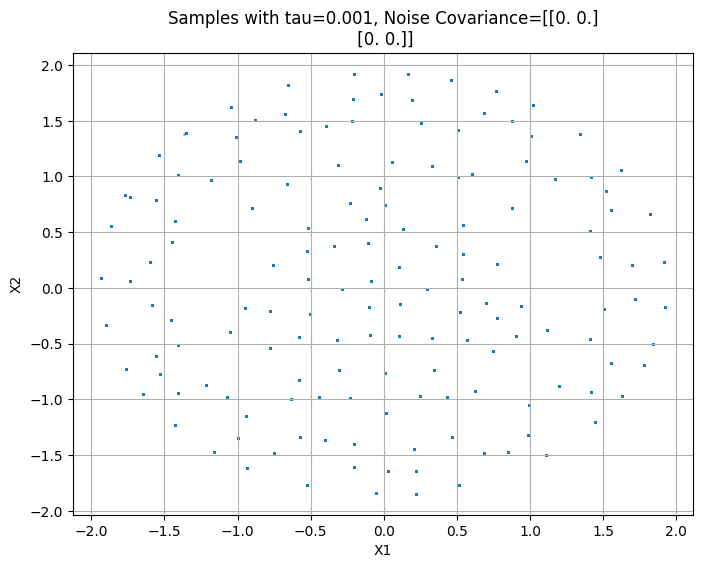

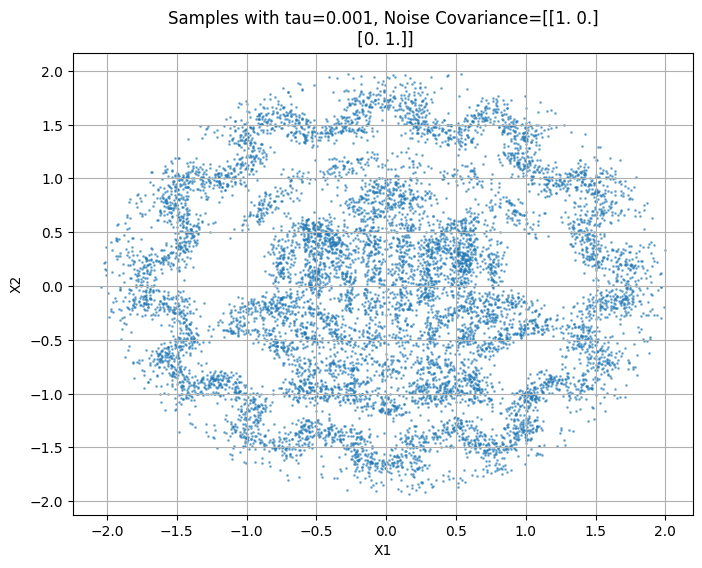

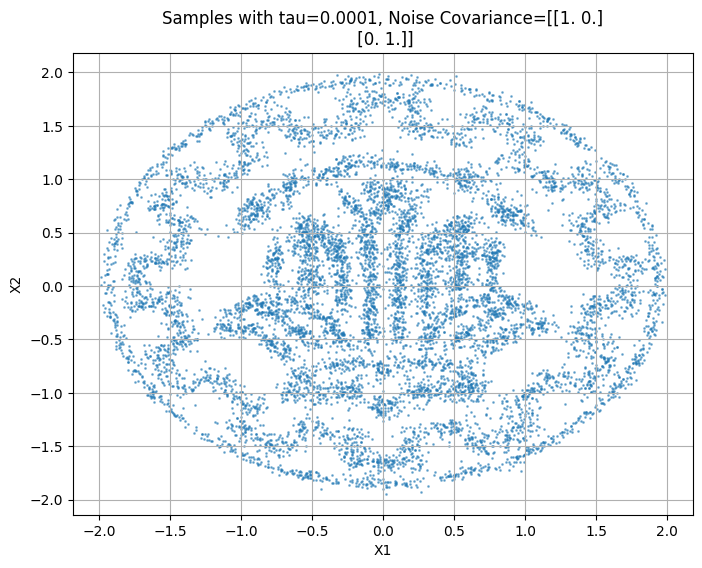

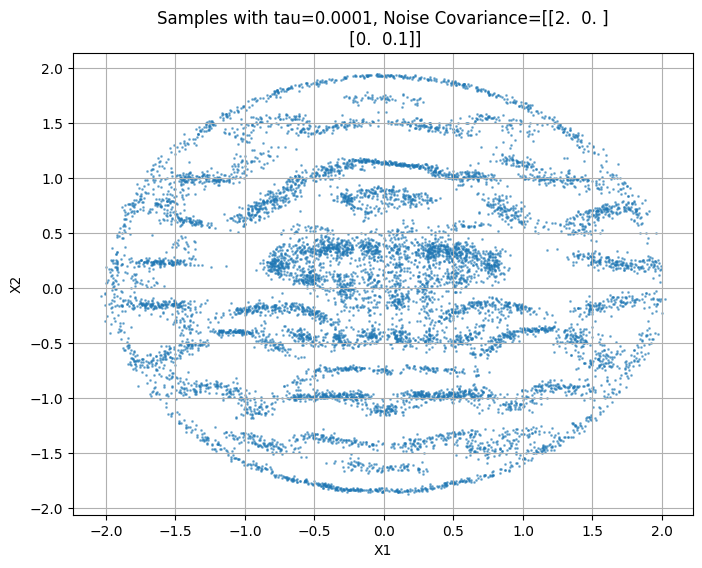

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load parameters from pickle file
parameters_file_path = 'DGM_SUT_H5_density.pkl'
with open(parameters_file_path, 'rb') as file:
    parameters = pickle.load(file)

# Simulation parameters
num_samples = 10 ** 4  # Number of initial samples
num_steps = 1000  # Number of simulation steps
tau_values = [1e-3, 1e-3, 1e-4, 1e-4]  # Different step sizes
batch_size = 500  # Batch size for processing samples
noise_covariances = [np.zeros((2, 2)), np.eye(2), np.eye(2),
                     np.array([[2.0, 0.0], [0.0, 0.1]])]  # Noise covariance options

# Extract GMM parameters
weights, means, covariances = parameters['weights'], parameters['means'], parameters['covariances']
precomputed_inv_cov = [np.linalg.inv(cov) for cov in covariances]
precomputed_det_cov = [np.linalg.det(cov) for cov in covariances]


def log_pi_batched(x_batch):
    """Log of the target GMM distribution (batched)."""
    gmm_log_pdf = np.zeros(len(x_batch))
    for w, mu, inv_cov, det_cov in zip(weights, means, precomputed_inv_cov, precomputed_det_cov):
        diff = x_batch - mu
        exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
        gmm_log_pdf += w * np.exp(exponent) / np.sqrt((2 * np.pi) ** len(mu) * det_cov)
    return np.log(gmm_log_pdf)


def gradient_log_pi_batched(x_batch):
    """Gradient of the log of the target GMM distribution (batched)."""
    grad = np.zeros_like(x_batch)
    for w, mu, inv_cov, det_cov in zip(weights, means, precomputed_inv_cov, precomputed_det_cov):
        diff = x_batch - mu
        exp_term = np.exp(-0.5 * np.sum(diff @ inv_cov * diff, axis=1))[:, None]
        grad += w * exp_term * (-diff @ inv_cov) / np.sqrt((2 * np.pi) ** len(mu) * det_cov)
    normalization = np.exp(log_pi_batched(x_batch))[:, None]
    return grad / normalization


def langevin_update_with_noise(x_batch, tau, noise_cov):
    """Perform a single Langevin update with noise."""
    grad = gradient_log_pi_batched(x_batch)
    noise = np.random.multivariate_normal(mean=np.zeros(noise_cov.shape[0]), cov=noise_cov, size=len(x_batch))
    return x_batch + tau * grad + np.sqrt(2 * tau) * noise


def simulate_and_plot(samples, tau, noise_cov, title):
    """Run Langevin dynamics and plot the results."""
    for _ in range(num_steps):
        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            samples[start:end] = langevin_update_with_noise(samples[start:end], tau, noise_cov)
    plt.figure(figsize=(8, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.show()


# Simulations with different tau and noise covariance configurations
for tau, noise_cov in zip(tau_values, noise_covariances):
    initial_samples = np.random.normal(0, 1, (num_samples, 2))
    simulate_and_plot(initial_samples, tau, noise_cov, f"Samples with tau={tau}, Noise Covariance={noise_cov}")


در این تمرین معادله دیفرانسیل داده‌شده را شبیه‌سازی کردیم.

### تفسیر مشاهدات:

---

#### **بخش اول: شبیه‌سازی بدون نویز $(\tau = 0.001$, نویز گاوسی حذف شده)**
- **نتیجه**: در این شبیه‌سازی، نمونه‌ها تنها تحت تأثیر گرادیان $\nabla \log \pi(X)$ حرکت کرده و به سمت نقاطی با بیشینه چگالی در توزیع هدف $\pi(X)$ هدایت شدند.
- **مشاهده**:
  - نمونه‌ها به‌صورت یکنواخت در فضای هدف توزیع شده‌اند، اما تنوع کافی ندارند.
  - نبود نویز باعث شده نمونه‌ها بیشتر به مناطق خاصی متمرکز شوند.
- **مزایا**:
  - فرآیند بدون نویز می‌تواند گرادیان توزیع هدف را با دقت بیشتری دنبال کند.
- **معایب**:
  - نبود نویز تنوع نمونه‌ها را محدود کرده و احتمال گیر افتادن در بیشینه‌های محلی را افزایش می‌دهد.

---

#### **بخش دوم: شبیه‌سازی با نویز ایزوتروپیک $(\tau = 0.001, \text{Cov} = \mathbf{I}$)**
- **نتیجه**: با افزودن نویز ایزوتروپیک (همسانگرد) به فرآیند، نمونه‌ها به نواحی بیشتری از توزیع هدف دسترسی پیدا کرده و توزیع نمونه‌ها متنوع‌تر شده است.
- **مشاهده**:
  - ساختار دایره‌ای توزیع هدف بهتر منعکس شده است.
  - نویز باعث شده که نمونه‌ها نواحی بیشتری از فضا را پوشش دهند.
- **مزایا**:
  - نویز به فرآیند کمک می‌کند تا از بیشینه‌های محلی خارج شود.
  - تنوع نمونه‌ها افزایش یافته است.
- **معایب**:
  - اگرچه تنوع نمونه‌ها افزایش یافته، اما دقت کمی کاهش پیدا کرده است.

---

#### **بخش سوم: شبیه‌سازی با نویز ایزوتروپیک و گام کوچک‌تر $(\tau = 0.0001$, $\text{Cov} = \mathbf{I}$)**
- **نتیجه**: کاهش مقدار گام $\tau$ به $0.0001$ باعث شده که نمونه‌ها با دقت بیشتری توزیع هدف را دنبال کنند.
- **مشاهده**:
  - پراکندگی نمونه‌ها در نواحی مختلف توزیع هدف بهتر توزیع شده است.
  - ساختار اصلی توزیع هدف (شکل حلقه‌ای یا دایره‌ای) به‌خوبی منعکس شده است.
- **مزایا**:
  - کاهش گام به مدل کمک می‌کند تا مسیر گرادیان را دقیق‌تر دنبال کند.
  - نمونه‌ها به توزیع هدف نزدیک‌تر هستند.
- **معایب**:
  - هزینه محاسباتی بالاتر به دلیل نیاز به گام‌های بیشتر برای رسیدن به همگرایی.

---

#### **بخش چهارم: شبیه‌سازی با نویز ناهمسانگرد $(\tau = 0.0001$, $\text{Cov} = \begin{bmatrix} 2 & 0 \\ 0 & 0.1 \end{bmatrix}$)**
- **نتیجه**: افزودن نویز ناهمسانگرد تأثیرات شدیدی بر شکل توزیع نمونه‌ها گذاشته و باعث تغییر فرم اصلی توزیع هدف شده است.
- **مشاهده**:
  - نمونه‌ها در جهت $X_1$ بیش‌ازحد پراکنده شده‌اند (به دلیل واریانس بالاتر 2.0).
  - در جهت $X_2$، نمونه‌ها به‌صورت فشرده‌تر و متمرکزتر قرار گرفته‌اند (به دلیل واریانس کمتر 0.1).
  - فرم اصلی توزیع هدف خراب شده و شکل نهایی با ساختار هدف هم‌خوانی کمتری دارد.
- **مزایا**:
  - نویز ناهمسانگرد تنوع بیشتری در جهات مختلف ایجاد کرده است.
- **معایب**:
  - نمونه‌ها از توزیع هدف منحرف شده‌اند.
  - فرم نهایی به درستی بازتاب‌دهنده توزیع هدف نیست.

---

### **مقایسه کلی و جمع‌بندی:**

| **بخش**      | **دقت در شبیه‌سازی توزیع هدف** | **تنوع نمونه‌ها** | **هزینه محاسباتی** | **تأثیر گرادیان و نویز** |
|---------------|-------------------------------|-------------------|--------------------|-------------------------|
| **بخش اول**   | متوسط                         | کم                | پایین              | فقط گرادیان، بدون نویز  |
| **بخش دوم**   | خوب                           | بالا              | متوسط              | نویز و گرادیان متعادل  |
| **بخش سوم**   | عالی                          | بالا              | بالا               | دقت بالاتر با گام کوچک |
| **بخش چهارم** | ضعیف                          | متوسط             | بالا               | نویز غالب، گرادیان کم‌رنگ |

---

### **پیشنهادها برای بهبود:**
1. **تنظیم ماتریس نویز**: استفاده از نویز ایزوتروپیک ($\text{Cov} = \mathbf{I}$) در بیشتر موارد نتیجه بهتری دارد، اما تنظیم دقیق نویز در حالت ناهمسانگرد می‌تواند مفید باشد.
2. **تنظیم مقدار گام**: مقدار $\tau$ باید به گونه‌ای انتخاب شود که بین سرعت همگرایی و دقت توزیع تعادل ایجاد کند. گام‌های کوچک‌تر برای دقت بالاتر و گام‌های بزرگ‌تر برای کاهش هزینه محاسباتی مناسب هستند.
3. **مقایسه با توزیع هدف واقعی**: برای ارزیابی دقیق‌تر، مقایسه نمودارها با توزیع واقعی هدف $\pi(X)$ ضروری است.
4. **ترکیب نویزهای مختلف**: استفاده از ترکیبی از نویز ایزوتروپیک و ناهمسانگرد می‌تواند تنوع و دقت را هم‌زمان افزایش دهد.

---

### **نتیجه نهایی:**
شبیه‌سازی بخش سوم بهترین تعادل را بین دقت و تنوع ارائه می‌دهد و بازتاب دقیقی از توزیع هدف است. اما در شرایطی که تنوع بالاتر یا سرعت بیشتر مورد نیاز است، می‌توان از تنظیمات دیگر (مانند بخش دوم) بهره برد. بخش چهارم نشان‌دهنده اثرات نامطلوب تنظیم اشتباه نویز است و اهمیت دقت در انتخاب پارامترها را برجسته می‌کند.

هم‌چنین در سلول دوم تمام بخش‌های تمرین را در حالتی که تعداد گام‌ها ۱۰۰۰تا باشد تکرار نموده و نتایج را نشان داده‌ایم. با این تنظیمات، شکل بخش اول به صورت اسپارس‌تر و با نقاط جداتر شده است، بخش دوم به شکل اصلی نزدیک‌تر شده است و بخش‌های سوم و چهارم نیز به همین صورت. در کل با اضافه کردن گام‌های شبیه‌سازی نتیجه‌ی به دست‌آمده دقیق‌تر می‌شود.
